In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Import Completed")

Import Completed


In [22]:
bot=pd.read_csv("CIC-IDS2017-Dataset\Botnet-Friday-no-metadata.parquet.csv")

In [23]:
bot.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,112740690,32,16,6448,1152,403,0,201.5,204.7242,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,498804.80,16400000,15400000,Benign
1,6,112740560,32,16,6448,5056,403,0,201.5,204.7242,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,498793.66,16400000,15400000,Benign
2,0,113757377,545,0,0,0,0,0,0.0,0.0000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6935824.00,20800000,5504997,Benign
3,17,100126,22,0,616,0,28,28,28.0,0.0000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.00,0,0,Benign
4,0,54760,4,0,0,0,0,0,0.0,0.0000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.00,0,0,Benign


In [24]:
print("\nCleaning headers and stripping broken rows...")

# Strip hidden leading/trailing spaces from column names
bot.columns = bot.columns.str.strip()

# Replace mathematical infinities with NaN, then drop them cleanly
bot.replace([np.inf, -np.inf], np.nan, inplace=True)
bot.dropna(inplace=True)

print("Data infrastructure validated and clean.")


Cleaning headers and stripping broken rows...
Data infrastructure validated and clean.



Analyzing target class distributions...
Label
Benign    174601
Bot         1437
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_26444\2443024125.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


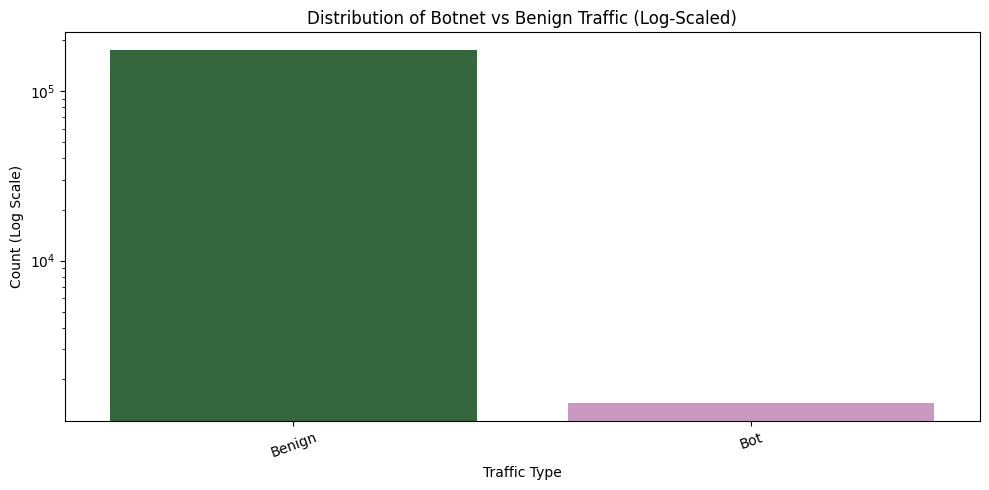

In [25]:
print("\nAnalyzing target class distributions...")

# Print the numerical breakdown of bots vs benign traffic
print(bot['Label'].value_counts())

# Generate Log-Scaled Count Plot
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=bot, 
    x='Label', 
    order=bot['Label'].value_counts().index, 
    palette='cubehelix'
)
ax.set_yscale('log')  # Force log scale so minority Botnet profiles are visible
plt.xticks(rotation=20)
plt.title('Distribution of Botnet vs Benign Traffic (Log-Scaled)')
plt.ylabel('Count (Log Scale)')
plt.xlabel('Traffic Type')
plt.tight_layout()
plt.show()


Plotting temporal pacing variations...


C:\Users\admin\AppData\Local\Temp\ipykernel_26444\235626724.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=bot, x='Label', y='Fwd IAT Std', palette='magma')


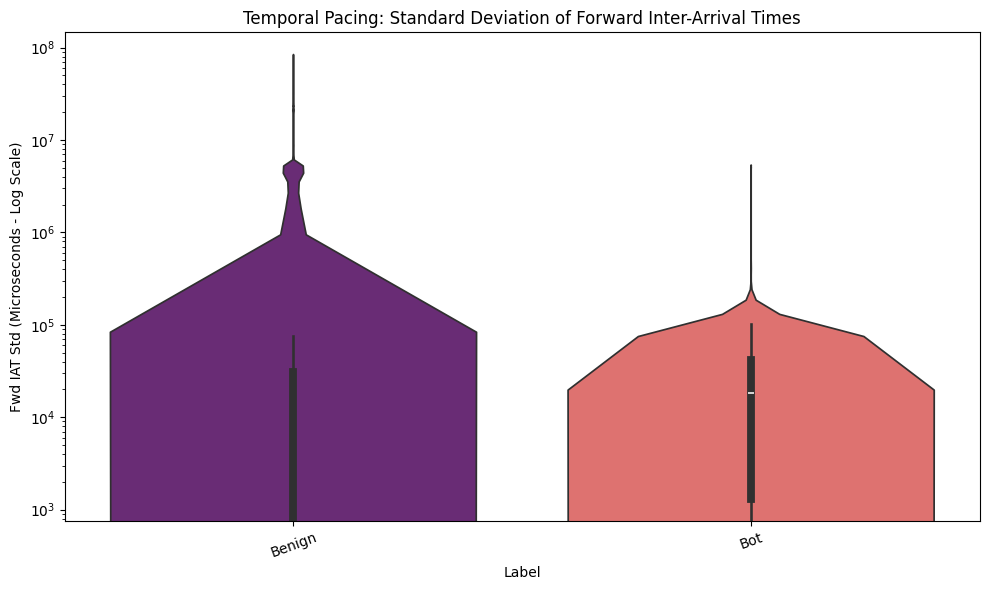

In [26]:
print("\nPlotting temporal pacing variations...")

plt.figure(figsize=(10, 6))
# Fwd IAT Std catches the rigid, machine-timed clock cycles of the Botnet
sns.violinplot(data=bot, x='Label', y='Fwd IAT Std', palette='magma')
plt.yscale('log')
plt.xticks(rotation=20)
plt.title('Temporal Pacing: Standard Deviation of Forward Inter-Arrival Times')
plt.ylabel('Fwd IAT Std (Microseconds - Log Scale)')
plt.tight_layout()
plt.show()


 Visualizing connection duration longevity...


C:\Users\admin\AppData\Local\Temp\ipykernel_26444\4075010538.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bot, x='Label', y='Idle Mean', palette='viridis')


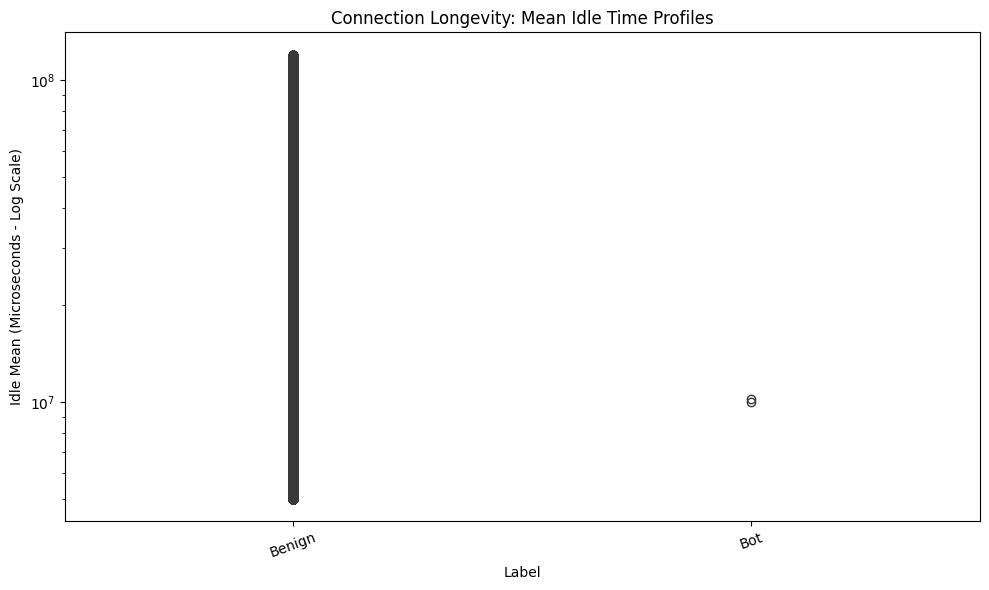

In [27]:
print("\n Visualizing connection duration longevity...")

plt.figure(figsize=(10, 6))
# Long, persistent idle blocks indicate a bot quietly waiting for commands
sns.boxplot(data=bot, x='Label', y='Idle Mean', palette='viridis')
plt.yscale('log')
plt.xticks(rotation=20)
plt.title('Connection Longevity: Mean Idle Time Profiles')
plt.ylabel('Idle Mean (Microseconds - Log Scale)')
plt.tight_layout()
plt.show()


Visualizing connection duration longevity (Distribution Comparison)...


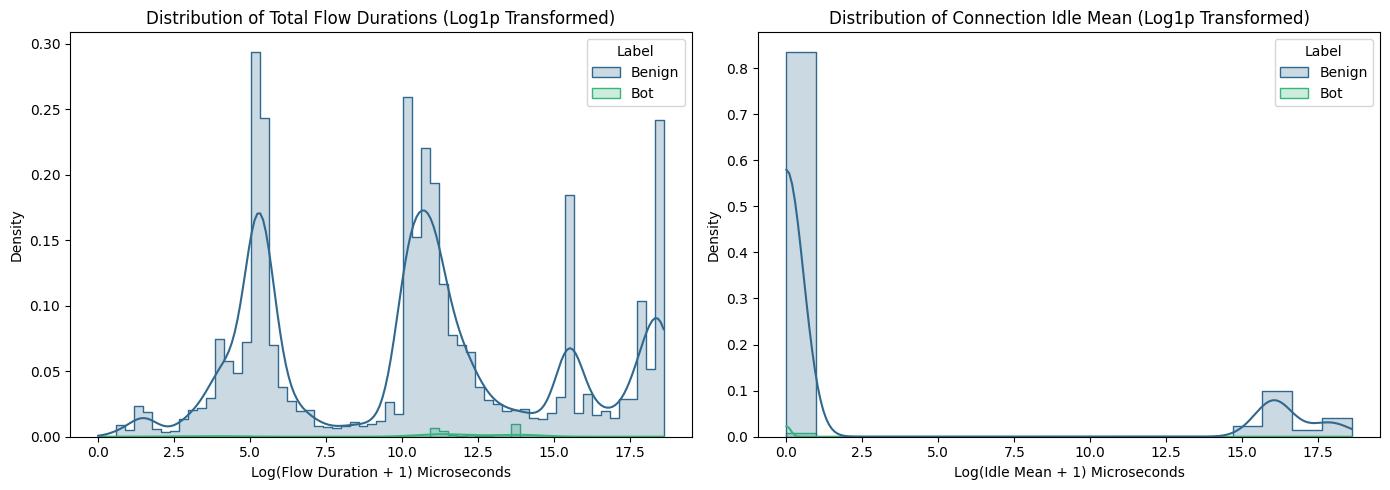

In [28]:
print("\nVisualizing connection duration longevity (Distribution Comparison)...")

# Setting up a side-by-side distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plotting Flow Duration Distribution (using log1p data transformation)
sns.histplot(
    data=bot, 
    x=np.log1p(bot['Flow Duration'].clip(lower=0)), 
    hue='Label', 
    kde=True, 
    element='step', 
    stat='density', 
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Distribution of Total Flow Durations (Log1p Transformed)')
axes[0].set_xlabel('Log(Flow Duration + 1) Microseconds')

# Plotting Idle Mean Distribution (using log1p data transformation to safely bypass 0 values)
sns.histplot(
    data=bot, 
    x=np.log1p(bot['Idle Mean'].clip(lower=0)), 
    hue='Label', 
    kde=True, 
    element='step', 
    stat='density', 
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Distribution of Connection Idle Mean (Log1p Transformed)')
axes[1].set_xlabel('Log(Idle Mean + 1) Microseconds')

plt.tight_layout()
plt.show()


Visualizing forward packet size structure...


C:\Users\admin\AppData\Local\Temp\ipykernel_26444\2288052641.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bot, x='Label', y='Fwd Packet Length Max', palette='plasma')


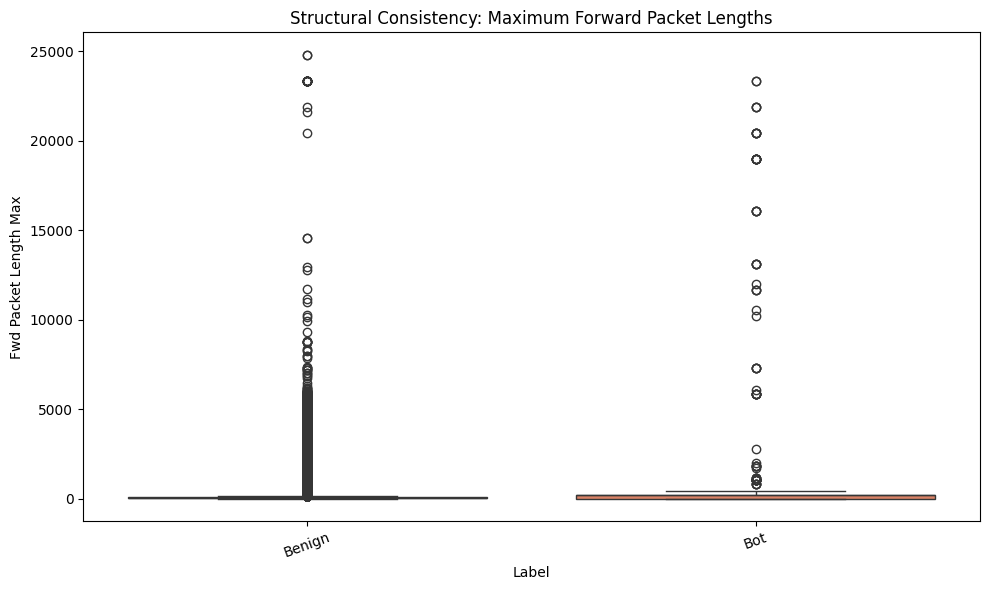

In [29]:
print("\nVisualizing forward packet size structure...")

plt.figure(figsize=(10, 6))
# Maximum packet lengths reveal the strict template sizing of command packets
sns.boxplot(data=bot, x='Label', y='Fwd Packet Length Max', palette='plasma')
plt.xticks(rotation=20)
plt.title('Structural Consistency: Maximum Forward Packet Lengths')
plt.tight_layout()
plt.show()

In [30]:
print("\n Executing botnet-specific feature engineering...")

# 1. Stability Coefficient (Comparing structural timing bounds)
bot['Pacing_Stability'] = bot['Fwd IAT Min'] / (bot['Fwd IAT Mean'] + 1)

# 2. Idle-to-Active Ratio (Exposes silent background check-ins)
bot['Idle_Active_Ratio'] = bot['Idle Mean'] / (bot['Active Mean'] + 1)

# 3. Data Smoothing log transformations with the lower bound clip fix
bot['Log_Flow_Duration'] = np.log1p(bot['Flow Duration'].clip(lower=0))
bot['Log_Fwd_IAT_Std'] = np.log1p(bot['Fwd IAT Std'].clip(lower=0))

print("Engineered behavioral features attached successfully with zero warnings!")


 Executing botnet-specific feature engineering...
Engineered behavioral features attached successfully with zero warnings!



Generating correlation heatmap to prune volumetric variables...


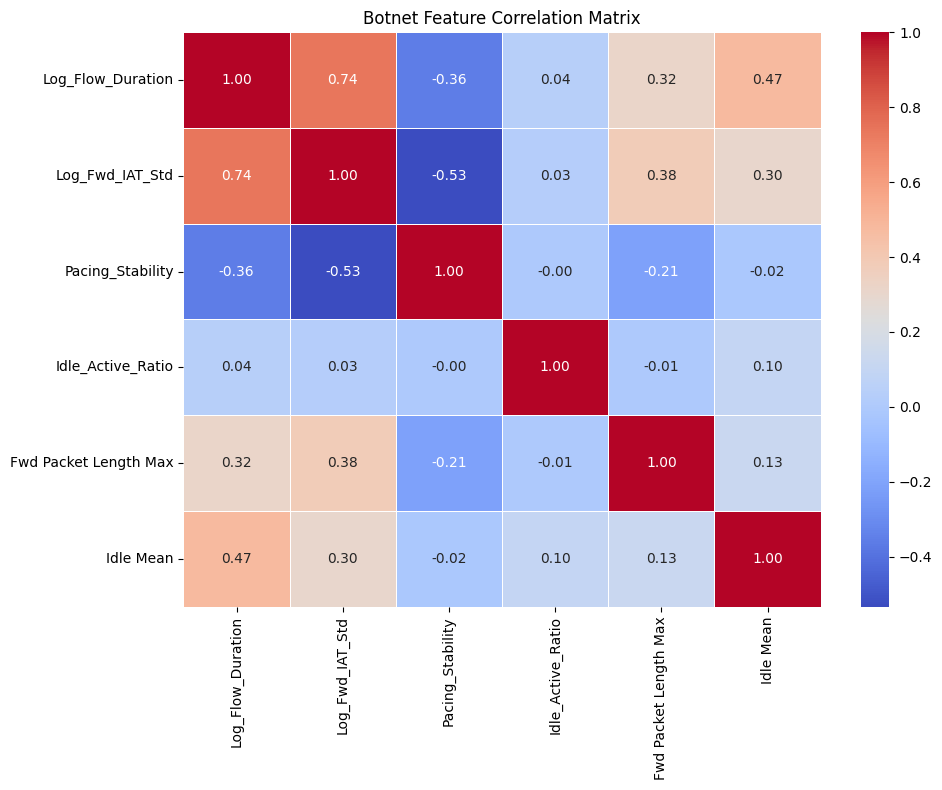

Dead features with zero informational variance: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Pipeline complete! The processed botnet data is optimized for ML modeling.


In [31]:
print("\nGenerating correlation heatmap to prune volumetric variables...")

# Isolate timing and newly engineered features, leaving out heavy volume metrics
botnet_features = [
    'Log_Flow_Duration', 'Log_Fwd_IAT_Std', 'Pacing_Stability', 
    'Idle_Active_Ratio', 'Fwd Packet Length Max', 'Idle Mean'
]

plt.figure(figsize=(10, 8))
corr_matrix = bot[botnet_features].corr()

# Draw the correlation grid
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Botnet Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Detect and print completely dead columns providing zero variance
zero_variance = [col for col in bot.columns if bot[col].nunique() == 1]
print(f"Dead features with zero informational variance: {zero_variance}")
print("\nPipeline complete! The processed botnet data is optimized for ML modeling.")